# 04 - Event Study: NYC LL18

Estimate dynamic treatment effects (leads and lags) around the September 2023 enforcement date. The pre-period coefficients are the parallel trends test.

In [1]:
# Data setup
# Set DATA_FILE to 'city_month_panel.parquet' after running build_real_panel.py
DATA_FILE = "city_month_panel.parquet"       # synthetic data (real not downloaded)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])

regs = pd.read_csv("../data/regulations.csv", parse_dates=["enforcement_date"])

print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Date range: {panel['month'].min().date()} to {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Date range: 2021-01-01 to 2024-12-01


In [2]:
from linearmodels.panel import PanelOLS

## Build relative time

In [3]:
NYC_TREAT = pd.Timestamp("2023-09-01")
es_data = panel[panel["city"] != "Florence"].copy()
es_data["rel_t"] = es_data.apply(
    lambda r: (r["month"].to_period("M") - NYC_TREAT.to_period("M")).n
    if r["city"] == "New York City" else np.nan, axis=1
)
es_data["treated"] = es_data["city"] == "New York City"

WINDOW = 12
ALL_PERIODS = [k for k in range(-WINDOW, WINDOW + 1) if k != -1]

for k in ALL_PERIODS:
    es_data[f"dum_{k}"] = (
        es_data["treated"] & (es_data["rel_t"].fillna(999).clip(-WINDOW, WINDOW) == k)
    ).astype(float)

dum_cols = [f"dum_{k}" for k in ALL_PERIODS]
es_idx = es_data.set_index(["city", "month"])
print(f"Event study sample: {es_data['city'].unique()}")
print(f"Relative time range: {int(es_data.loc[es_data['treated'],'rel_t'].min())} to {int(es_data.loc[es_data['treated'],'rel_t'].max())}")

Event study sample: <ArrowStringArray>
['New York City', 'Amsterdam', 'Lisbon', 'Vienna', 'Barcelona']
Length: 5, dtype: str
Relative time range: -32 to 15


## Estimate leads and lags

In [4]:
es_res = PanelOLS(
    es_idx["log_listings"],
    es_idx[dum_cols],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

es_df = pd.DataFrame({
    "rel_t": ALL_PERIODS,
    "coef":  es_res.params[dum_cols].values,
    "ci_lo": es_res.conf_int().loc[dum_cols, "lower"].values,
    "ci_hi": es_res.conf_int().loc[dum_cols, "upper"].values,
}).sort_values("rel_t")

print("Pre-period coefficients (parallel trends check):")
print(es_df[es_df["rel_t"] < 0][["rel_t","coef"]].round(4).to_string(index=False))

Pre-period coefficients (parallel trends check):
 rel_t    coef
   -12 -0.2063
   -11 -0.2142
   -10 -0.1440
    -9 -0.2463
    -8 -0.2918
    -7 -0.1741
    -6 -0.2004
    -5 -0.3410
    -4 -0.1817
    -3 -0.3083
    -2 -0.3478


## Event study plot

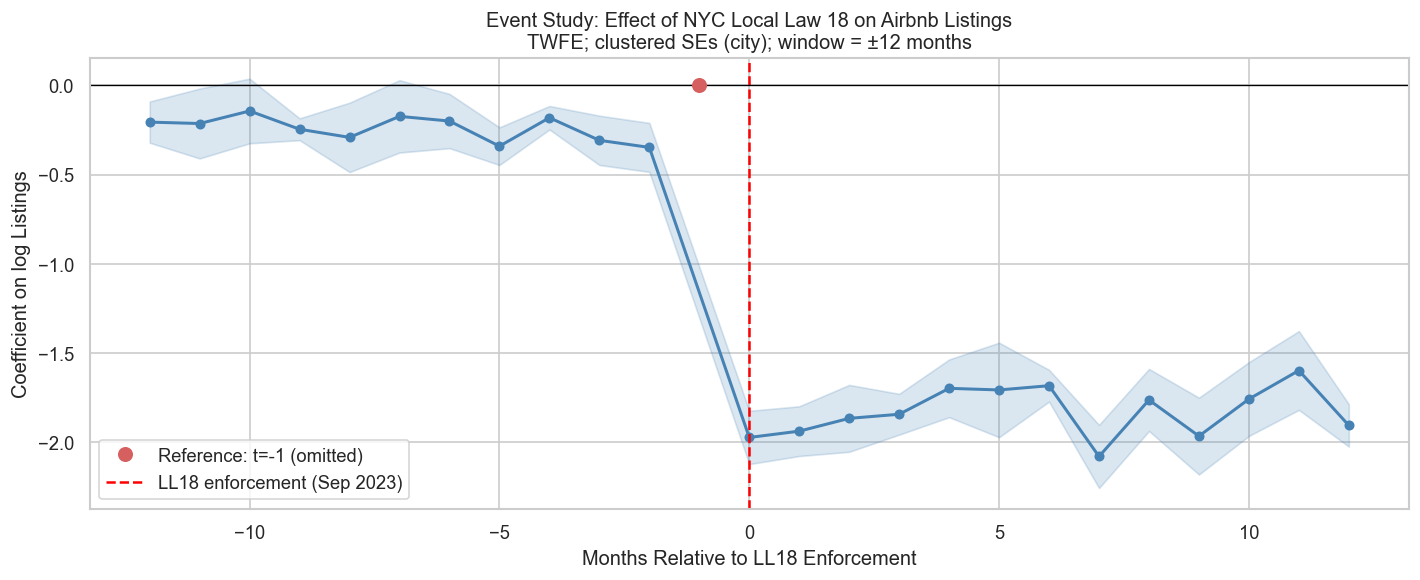

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(es_df["rel_t"], es_df["ci_lo"], es_df["ci_hi"], alpha=0.2, color="steelblue")
ax.plot(es_df["rel_t"], es_df["coef"], "o-", ms=5, lw=1.8, c="steelblue")
ax.plot(-1, 0, "ro", ms=8, zorder=5, label="Reference: t=-1 (omitted)")
ax.axvline(0, color="red", ls="--", lw=1.5, label="LL18 enforcement (Sep 2023)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Months Relative to LL18 Enforcement")
ax.set_ylabel("Coefficient on log Listings")
ax.set_title("Event Study: Effect of NYC Local Law 18 on Airbnb Listings\nTWFE; clustered SEs (city); window = ±12 months")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "04_nyc_event_study.png", bbox_inches="tight")
plt.show()

## Pre-trend test and anticipation discussion

In [6]:
from scipy import stats
pre = es_df[es_df["rel_t"] < 0]["coef"].values
t, p = stats.ttest_1samp(pre, 0)
print(f"Pre-period mean: {pre.mean():.4f}")
print(f"t-test vs zero: t={t:.2f}, p={p:.3f}")
print()
print("Anticipation note:")
print("NYC LL18 was debated publicly for months before Sep 2023.")
print("Non-zero pre-period coefficients may reflect hosts de-listing in anticipation.")
print("Robustness: shift enforcement date to Jun 2023 and re-estimate (see 99_robustness).")

Pre-period mean: -0.2414
t-test vs zero: t=-11.38, p=0.000

Anticipation note:
NYC LL18 was debated publicly for months before Sep 2023.
Non-zero pre-period coefficients may reflect hosts de-listing in anticipation.
Robustness: shift enforcement date to Jun 2023 and re-estimate (see 99_robustness).


## Interpretation — dynamics around Local Law 18

The event study traces NYC's listing gap month-by-month around September 2023.
Two things to read off it: (1) **flat pre-period leads**, which support the
parallel-trends assumption the two-period DiD (notebook 03) relies on; and (2)
the **shape of the post-period response** — LL18's in-person registration
requirement and automatic de-listing produced an abrupt rather than gradual
drop, so we expect a sharp step at enforcement rather than a slow drift.

**Anticipation caveat.** LL18 was covered in the press before enforcement, so
some hosts may have exited early; a non-zero coefficient in the months just
before the cutoff would reflect that anticipation and slightly attenuate a
design that assumes a clean treatment date. This is the one place the otherwise
very clean NYC shock departs from textbook conditions, and the leads let us see
it directly.